In [2]:
import pandas as pd

df = pd.read_csv("dataset/predictive_maintenance.csv")

print(f"Shape: {df.shape}")
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")

Shape: (10000, 10)
Строк: 10000, Столбцов: 10


In [3]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                   str
dtype: object

In [4]:
df.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure


## Качество данных

### 1. Пропущенные значения

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({
    "Пропусков": missing,
    "% от всех": missing_pct
}).query("`Пропусков` >= 0").sort_values("Пропусков", ascending=False)

,Пропусков,% от всех
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Target,0,0.0
Failure Type,0,0.0


### 2. Дубликаты

In [6]:
dupes = df.duplicated().sum()
print(f"Полных дубликатов: {dupes} ({dupes / len(df) * 100:.2f}%)")

df[df.duplicated(keep=False)].head(10)

Полных дубликатов: 0 (0.00%)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type


### 3. Некорректные типы

In [7]:
numeric_cols = ["Air temperature [K]", "Process temperature [K]",
                "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

issues = []
for col in numeric_cols:
    non_numeric = pd.to_numeric(df[col], errors="coerce").isnull().sum()
    if non_numeric > 0:
        issues.append({"Столбец": col, "Нечисловых значений": non_numeric})

if issues:
    pd.DataFrame(issues)
else:
    print("Все числовые столбцы содержат корректные типы.")

Все числовые столбцы содержат корректные типы.


### 4. Аномальные значения (выбросы)

In [8]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR)))

pd.DataFrame({
    "Выбросов (IQR)": outlier_mask.sum(),
    "% от всех": (outlier_mask.sum() / len(df) * 100).round(2),
    "Min": df[numeric_cols].min(),
    "Max": df[numeric_cols].max(),
})

,Выбросов (IQR),% от всех,Min,Max
Air temperature [K],0,0.00,295.3,304.5
Process temperature [K],0,0.00,305.7,313.8
Rotational speed [rpm],418,4.18,1168.0,2886.0
Torque [Nm],69,0.69,3.8,76.6
Tool wear [min],0,0.00,0.0,253.0


### 5. Ошибки ввода

In [9]:
errors = {}

required_cols = [
    "Type",
    "Target",
    "Failure Type",
    "Air temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Отсутствуют столбцы: {missing}")

# Недопустимые значения Type
valid_types = {"L", "M", "H"}
bad_type = df["Type"].notna() & ~df["Type"].isin(valid_types)

if bad_type.any():
    errors["Type — недопустимые значения"] = (
        df.loc[bad_type, "Type"].unique().tolist()
    )

# Target должен быть только 0 или 1
bad_target = df["Target"].notna() & ~df["Target"].isin([0, 1])

if bad_target.any():
    errors["Target — не 0/1"] = (
        df.loc[bad_target, "Target"].unique().tolist()
    )

# Физически невозможные значения
bad_temp = df["Air temperature [K]"] <= 0
if bad_temp.any():
    errors["Air temperature — отрицательная/нулевая"] = int(bad_temp.sum())

bad_speed = df["Rotational speed [rpm]"] < 0
if bad_speed.any():
    errors["Rotational speed — отрицательная"] = int(bad_speed.sum())

bad_torque = df["Torque [Nm]"] < 0
if bad_torque.any():
    errors["Torque — отрицательный"] = int(bad_torque.sum())

bad_wear = df["Tool wear [min]"] < 0
if bad_wear.any():
    errors["Tool wear — отрицательный"] = int(bad_wear.sum())

# Проверка согласованности Target и Failure Type
failure = df["Failure Type"].fillna("UNKNOWN")

mismatch = (
    ((df["Target"] == 0) & (failure != "No Failure")) |
    ((df["Target"] == 1) & (failure == "No Failure"))
)

if mismatch.any():
    errors["Target / Failure Type — несоответствие"] = int(mismatch.sum())

# Вывод результата
if errors:
    result = pd.DataFrame(
        list(errors.items()),
        columns=["Проверка", "Значение/Кол-во"]
    )
    display(result)
else:
    print("Ошибок ввода не обнаружено.")

,Проверка,Значение/Кол-во
0,Target / Failure Type — несоответствие,27


In [10]:
mismatch_mask = (
    ((df["Target"] == 0) & (df["Failure Type"] != "No Failure")) |
    ((df["Target"] == 1) & (df["Failure Type"] == "No Failure"))
)

df = df[~mismatch_mask].reset_index(drop=True)

print(f"Удалено строк: {mismatch_mask.sum()}")
print(f"Осталось строк: {len(df)}")

Удалено строк: 27
Осталось строк: 9973


In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
numeric_cols = ["Air temperature [K]", "Process temperature [K]",
                "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

## Разведочный анализ данных (EDA)

### 1. Распределение целевой переменной

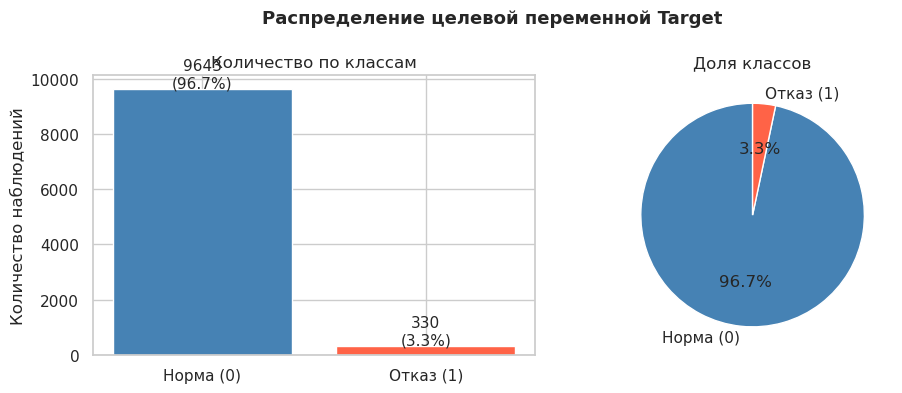

In [12]:
counts = df["Target"].value_counts()
labels = ["Норма (0)", "Отказ (1)"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, counts.values, color=["steelblue", "tomato"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=11)
axes[0].set_title("Количество по классам")
axes[0].set_ylabel("Количество наблюдений")

axes[1].pie(counts.values, labels=labels, autopct="%1.1f%%",
            colors=["steelblue", "tomato"], startangle=90)
axes[1].set_title("Доля классов")

plt.suptitle("Распределение целевой переменной Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2. Распределение числовых признаков

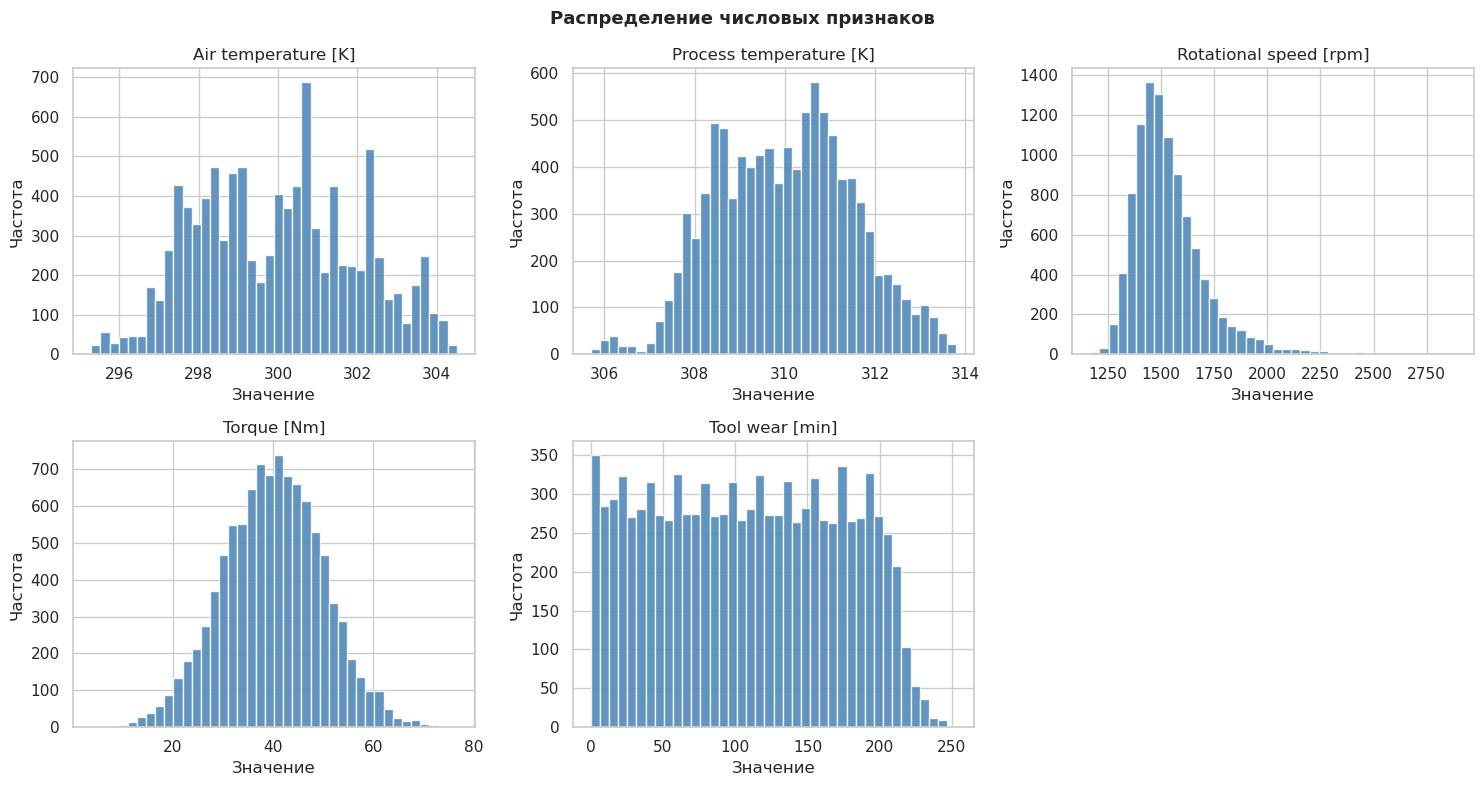

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel("Значение")
    axes[i].set_ylabel("Частота")

axes[-1].set_visible(False)
plt.suptitle("Распределение числовых признаков", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3. Распределение признаков по классам (норма vs отказ)

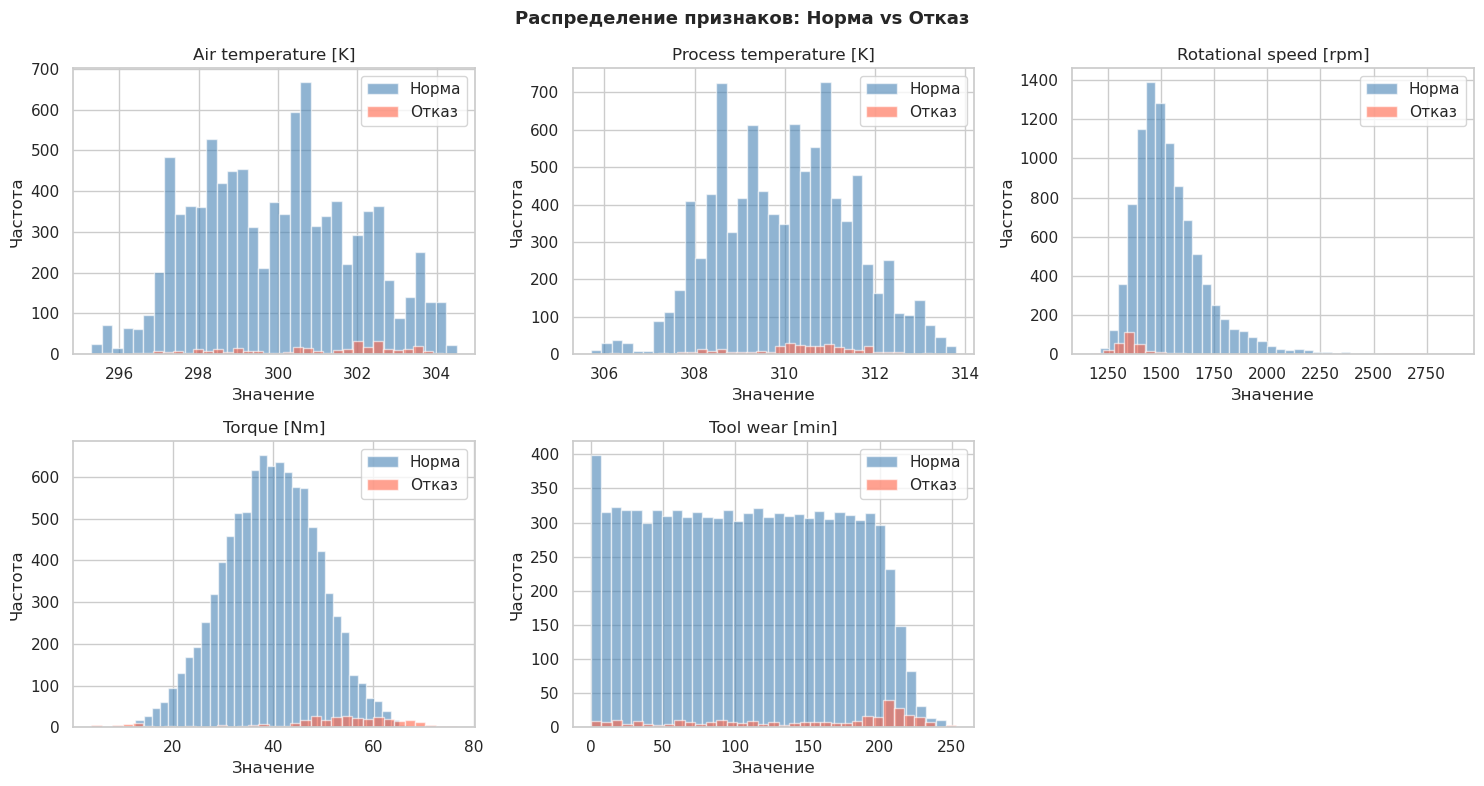

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for target, color, label in [(0, "steelblue", "Норма"), (1, "tomato", "Отказ")]:
        subset = df[df["Target"] == target][col]
        axes[i].hist(subset, bins=35, alpha=0.6, color=color, label=label, edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("Значение")
    axes[i].set_ylabel("Частота")
    axes[i].legend()

axes[-1].set_visible(False)
plt.suptitle("Распределение признаков: Норма vs Отказ", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4. Матрица корреляций

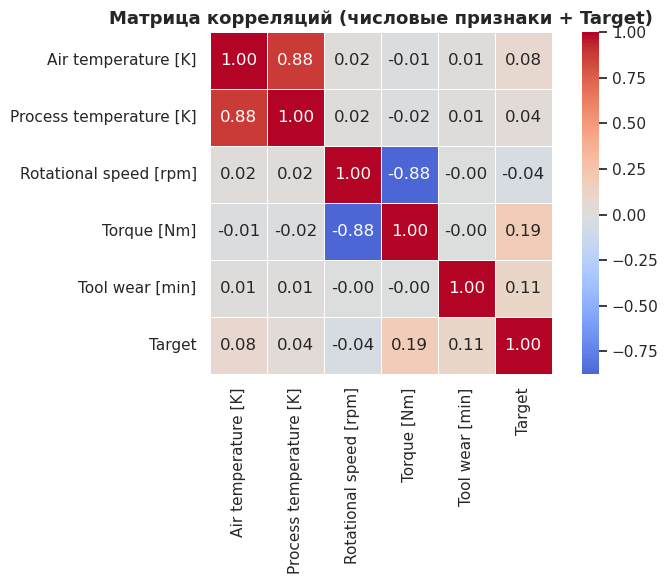

In [15]:
corr = df[numeric_cols + ["Target"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = corr.isnull()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, square=True)
ax.set_title("Матрица корреляций (числовые признаки + Target)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 5. Анализ типов отказов

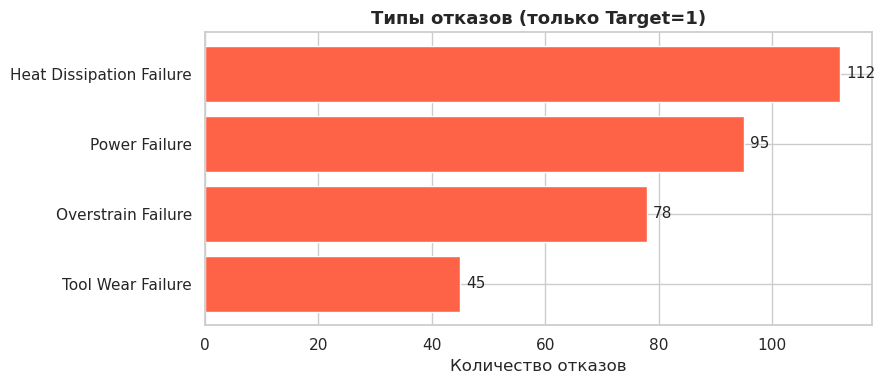

In [16]:
failure_counts = (
    df[df["Target"] == 1]["Failure Type"]
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(failure_counts.index, failure_counts.values, color="tomato", edgecolor="white")
for bar, val in zip(bars, failure_counts.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=11)
ax.set_xlabel("Количество отказов")
ax.set_title("Типы отказов (только Target=1)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 6. Распределение по типу продукта (L / M / H)

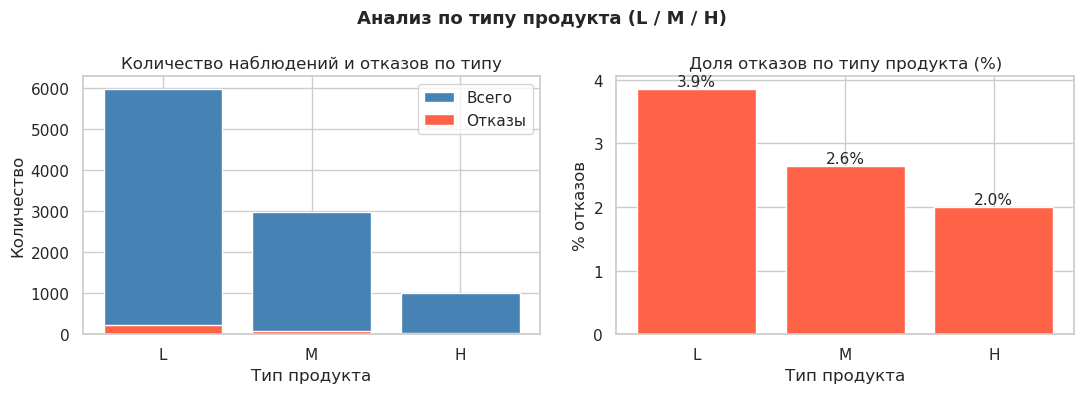

,total,failures,failure_rate
Type,,,
L,5984,231,3.860294
M,2991,79,2.641257
H,998,20,2.004008


In [17]:
type_stats = (
    df.groupby("Type")["Target"]
    .agg(total="count", failures="sum")
    .assign(failure_rate=lambda x: x["failures"] / x["total"] * 100)
    .loc[["L", "M", "H"]]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(type_stats.index, type_stats["total"], color="steelblue", label="Всего")
axes[0].bar(type_stats.index, type_stats["failures"], color="tomato", label="Отказы")
axes[0].set_title("Количество наблюдений и отказов по типу")
axes[0].set_xlabel("Тип продукта")
axes[0].set_ylabel("Количество")
axes[0].legend()

axes[1].bar(type_stats.index, type_stats["failure_rate"], color="tomato", edgecolor="white")
for i, (idx, row) in enumerate(type_stats.iterrows()):
    axes[1].text(i, row["failure_rate"] + 0.05, f"{row['failure_rate']:.1f}%", ha="center", fontsize=11)
axes[1].set_title("Доля отказов по типу продукта (%)")
axes[1].set_xlabel("Тип продукта")
axes[1].set_ylabel("% отказов")

plt.suptitle("Анализ по типу продукта (L / M / H)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

display(type_stats)

### 7. Tool wear vs отказы

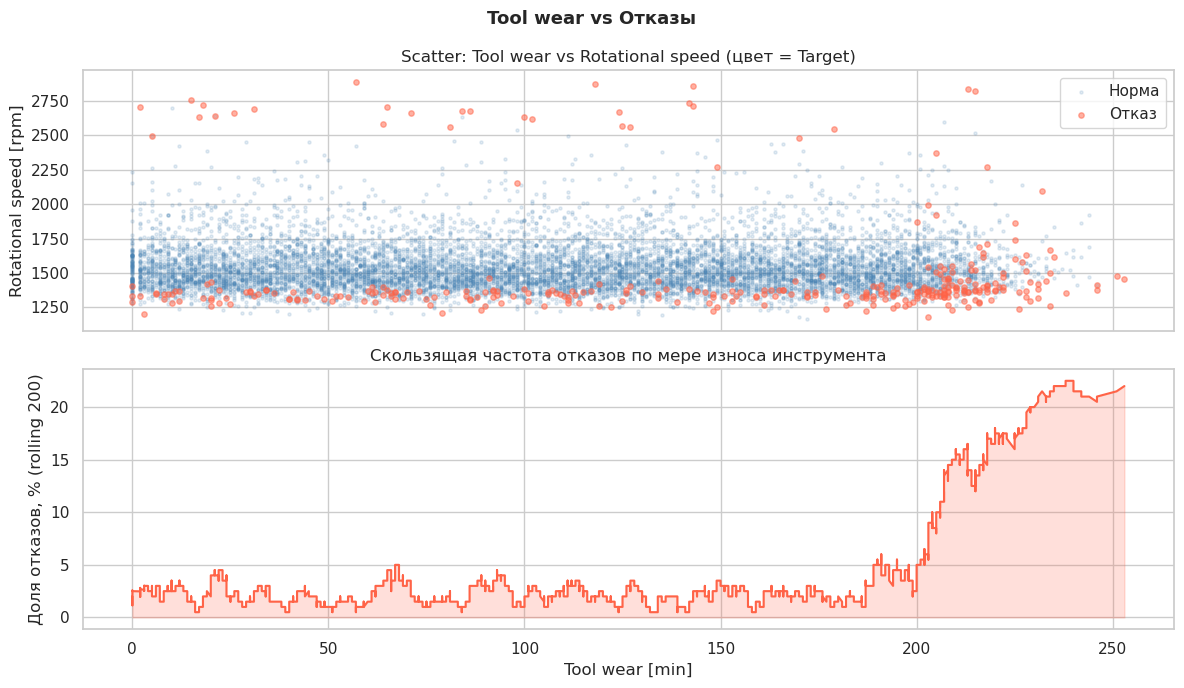

In [18]:
df_sorted = df.sort_values("Tool wear [min]").copy()
rolling_rate = df_sorted["Target"].rolling(window=200, min_periods=50).mean() * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].scatter(
    df[df["Target"] == 0]["Tool wear [min]"],
    df[df["Target"] == 0]["Rotational speed [rpm]"],
    alpha=0.15, s=5, color="steelblue", label="Норма"
)
axes[0].scatter(
    df[df["Target"] == 1]["Tool wear [min]"],
    df[df["Target"] == 1]["Rotational speed [rpm]"],
    alpha=0.5, s=15, color="tomato", label="Отказ"
)
axes[0].set_ylabel("Rotational speed [rpm]")
axes[0].set_title("Scatter: Tool wear vs Rotational speed (цвет = Target)")
axes[0].legend()

axes[1].plot(df_sorted["Tool wear [min]"], rolling_rate, color="tomato", linewidth=1.5)
axes[1].fill_between(df_sorted["Tool wear [min]"], rolling_rate, alpha=0.2, color="tomato")
axes[1].set_xlabel("Tool wear [min]")
axes[1].set_ylabel("Доля отказов, % (rolling 200)")
axes[1].set_title("Скользящая частота отказов по мере износа инструмента")

plt.suptitle("Tool wear vs Отказы", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 8. Парные зависимости (pairplot)

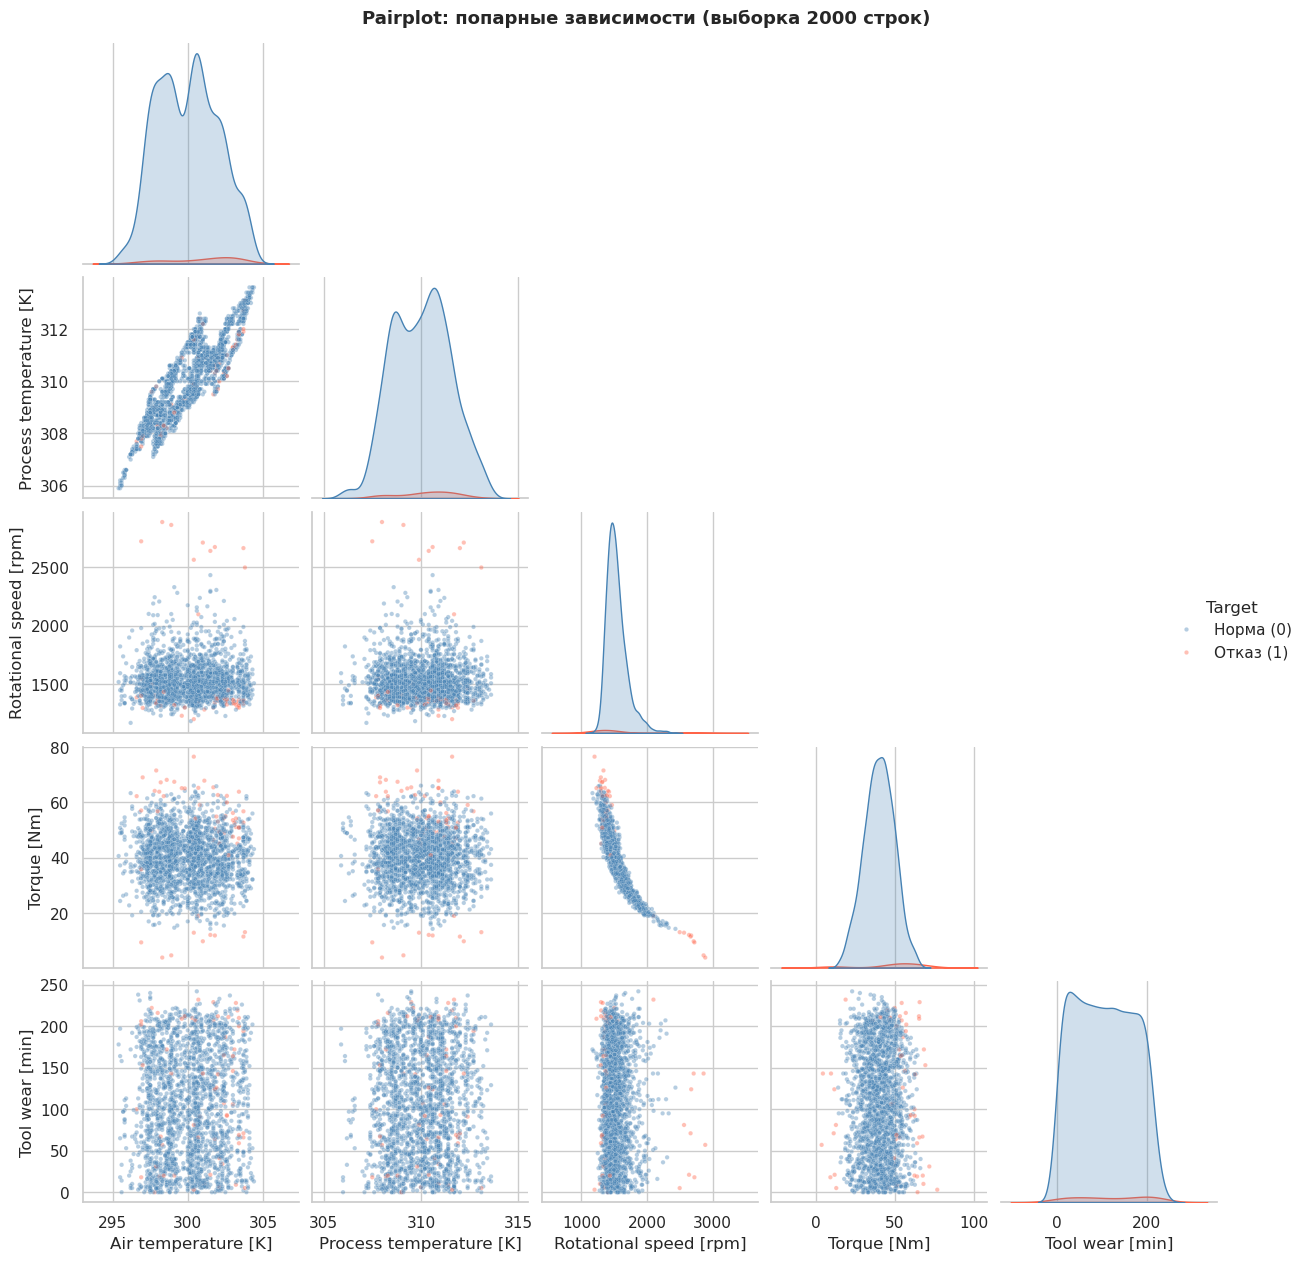

In [19]:
sample = df.sample(n=2000, random_state=42)

g = sns.pairplot(
    sample[numeric_cols + ["Target"]],
    hue="Target",
    palette={0: "steelblue", 1: "tomato"},
    plot_kws={"alpha": 0.4, "s": 10},
    diag_kind="kde",
    corner=True,
)
g.figure.suptitle("Pairplot: попарные зависимости (выборка 2000 строк)", y=1.01,
                   fontsize=13, fontweight="bold")
g._legend.set_title("Target")
for t, label in zip(g._legend.texts, ["Норма (0)", "Отказ (1)"]):
    t.set_text(label)
plt.show()

### 9. Статистическая сводка по классам

In [20]:
stats_normal = df[df["Target"] == 0][numeric_cols].describe().T
stats_failure = df[df["Target"] == 1][numeric_cols].describe().T

stats_combined = stats_normal[["mean", "std", "min", "max"]].rename(columns={
    "mean": "Норма — среднее", "std": "Норма — std",
    "min": "Норма — min", "max": "Норма — max"
}).join(stats_failure[["mean", "std", "min", "max"]].rename(columns={
    "mean": "Отказ — среднее", "std": "Отказ — std",
    "min": "Отказ — min", "max": "Отказ — max"
})).round(2)

stats_combined

,Норма — среднее,Норма — std,Норма — min,Норма — max,Отказ — среднее,Отказ — std,Отказ — min,Отказ — max
Air temperature [K],299.97,1.99,295.3,304.5,300.90,2.07,295.6,304.4
Process temperature [K],309.99,1.49,305.7,313.8,310.29,1.37,306.1,313.7
Rotational speed [rpm],1540.35,167.47,1168.0,2695.0,1496.18,389.59,1181.0,2886.0
Torque [Nm],39.62,9.47,12.6,70.0,50.40,16.46,3.8,76.6
Tool wear [min],106.67,62.94,0.0,246.0,144.51,72.94,0.0,253.0


### 10. Анализ типов отказов по признакам

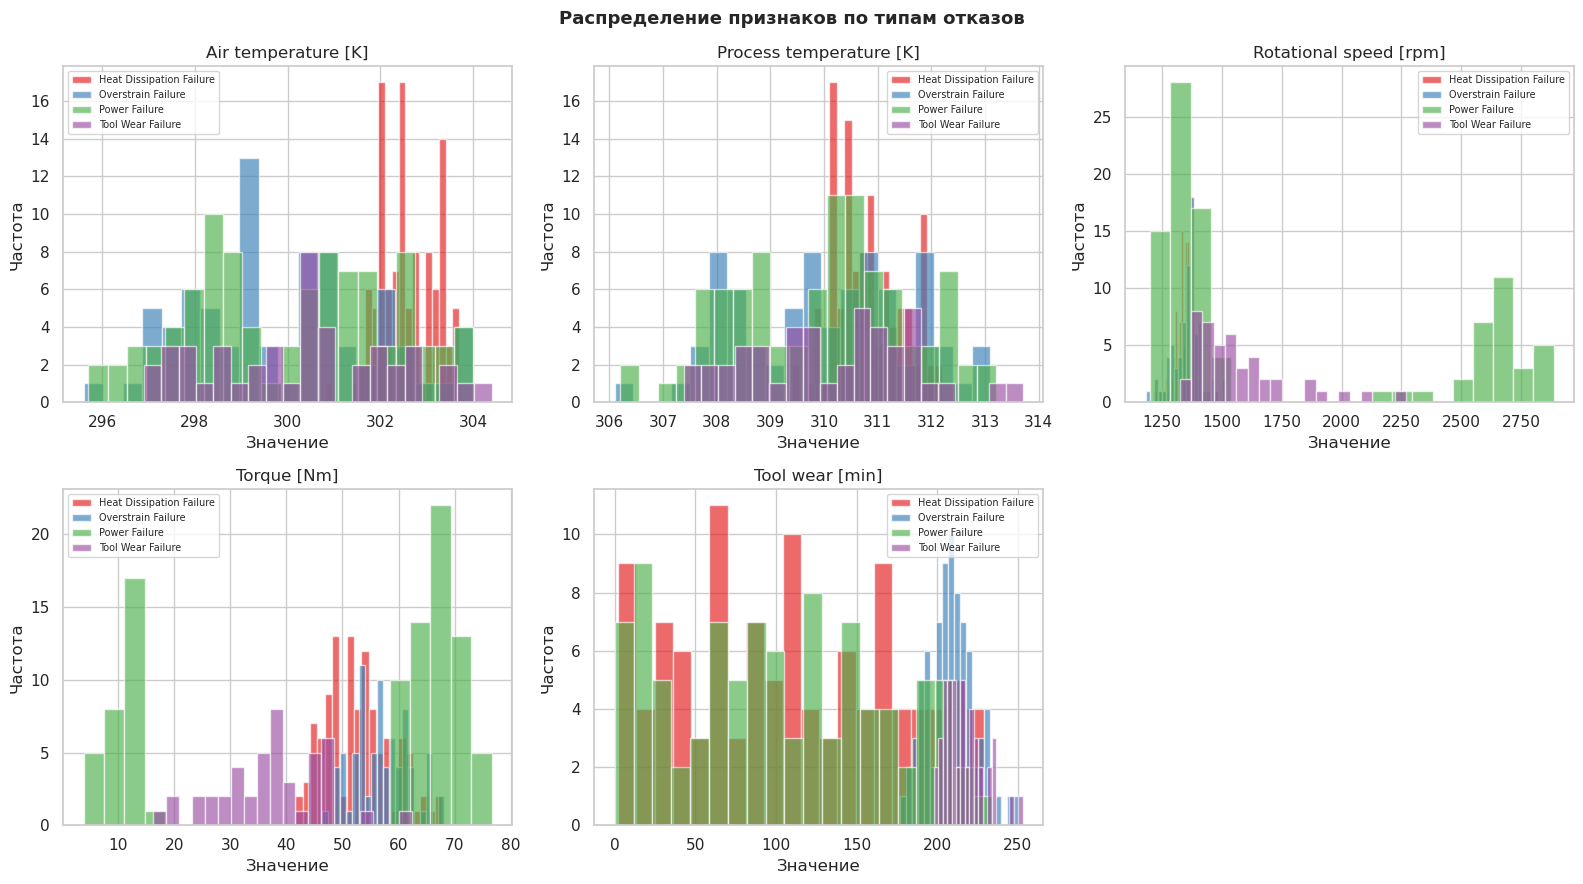

In [21]:
df_failures = df[df["Target"] == 1].copy()
colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]
failure_types = sorted(df_failures["Failure Type"].unique())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for j, ftype in enumerate(failure_types):
        vals = df_failures[df_failures["Failure Type"] == ftype][col]
        axes[i].hist(vals, bins=20, alpha=0.65, label=ftype,
                     color=colors[j], edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("Значение")
    axes[i].set_ylabel("Частота")
    axes[i].legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle("Распределение признаков по типам отказов", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 11. Box plot признаков по классам

/tmp/ipykernel_31559/306003416.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_class, patch_artist=True,
/tmp/ipykernel_31559/306003416.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_class, patch_artist=True,
/tmp/ipykernel_31559/306003416.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_class, patch_artist=True,
/tmp/ipykernel_31559/306003416.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp 

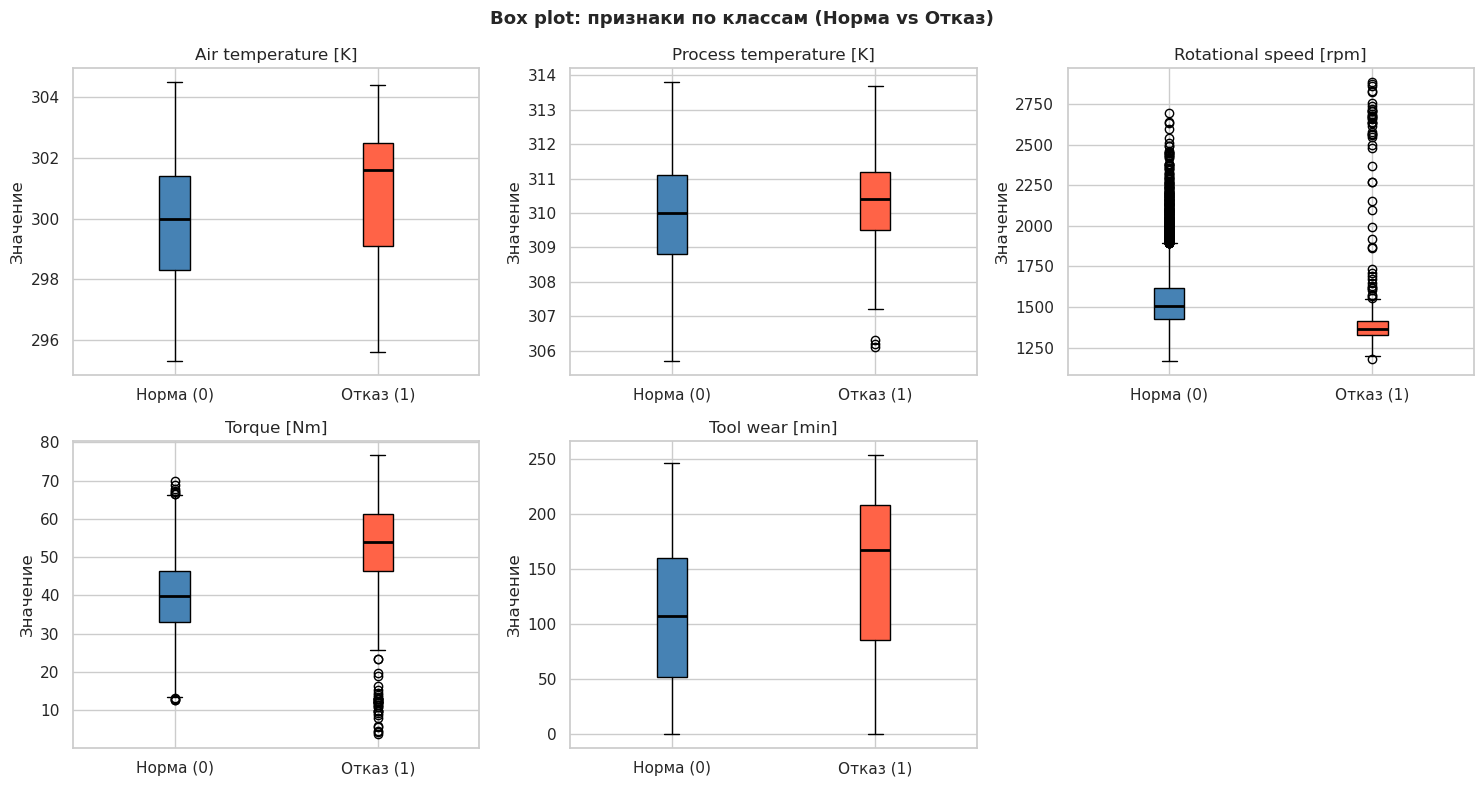

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data_by_class = [
        df[df["Target"] == 0][col].values,
        df[df["Target"] == 1][col].values,
    ]
    bp = axes[i].boxplot(data_by_class, patch_artist=True,
                         labels=["Норма (0)", "Отказ (1)"],
                         medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][1].set_facecolor("tomato")
    axes[i].set_title(col)
    axes[i].set_ylabel("Значение")

axes[-1].set_visible(False)
plt.suptitle("Box plot: признаки по классам (Норма vs Отказ)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 12. Тепловая карта отказов (Type × Failure Type)

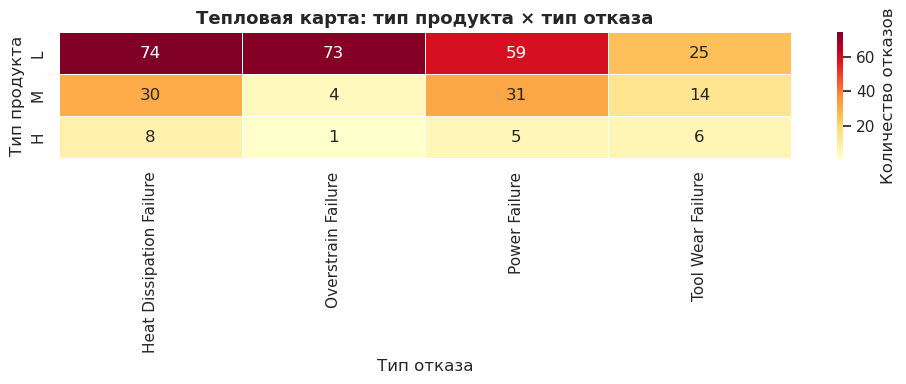

Failure Type,Heat Dissipation Failure,Overstrain Failure,Power Failure,Tool Wear Failure
Type,,,,
L,74,73,59,25
M,30,4,31,14
H,8,1,5,6


In [23]:
pivot = (
    df[df["Target"] == 1]
    .groupby(["Type", "Failure Type"])
    .size()
    .unstack(fill_value=0)
    .loc[["L", "M", "H"]]
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Количество отказов"})
ax.set_title("Тепловая карта: тип продукта × тип отказа", fontsize=13, fontweight="bold")
ax.set_xlabel("Тип отказа")
ax.set_ylabel("Тип продукта")
plt.tight_layout()
plt.show()

display(pivot)

## Сохранение очищенного датасета

In [24]:
df.to_csv("dataset/predictive_maintenance_clean.csv", index=False)

print(f"Сохранено: dataset/predictive_maintenance_clean.csv")
print(f"Строк: {len(df)}, Столбцов: {len(df.columns)}")

Сохранено: dataset/predictive_maintenance_clean.csv
Строк: 9973, Столбцов: 10
